### $$\text{INTERPRETABILIDAD DE MODELOS}$$

Orden cuaderno: 🔲codificado 🔲ejecutado

> ✅🅿 0. Importación de librerías

> ✅🅿 1. carga y limpieza de datos

> ✅🅿 2. Entrenamiento de modelos

> ✅🅿 3. Feature Importances - Interpretabilidad global

> ✅🅿 4. SHAP - Tree Explainer

> ✅🅿 5. LIME - Interpretabilidad local

> 🔲🅿 6. Conclusiones

# 0. Importar librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tabulate

# Preprocesamiento y Métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import precision_score, recall_score

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


c:\Users\HP ENVY\AppData\Local\pypoetry\Cache\virtualenvs\ejercicio-clase-boosting-LZc5TFcY-py3.11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Interpretabilidad
from sklearn.inspection import PartialDependenceDisplay
import lime
import lime.lime_tabular
import shap

In [ ]:
# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

# 1. carga y limpieza de datos

Leer archivo con df_trabajo:

In [ ]:
dftrabajo = pd.read_csv('../data/df_trabajo_sesiones.csv', sep=",")

In [ ]:
dftrabajo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22284 entries, 0 to 22283
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pais                 22284 non-null  object 
 1   num_visitas          22284 non-null  int64  
 2   numero_modelos       22284 non-null  int64  
 3   pagina_mas_visitada  22284 non-null  object 
 4   precio_maximo        22284 non-null  int64  
 5   precio_promedio      22284 non-null  float64
 6   visitaspag1trousers  22284 non-null  float64
 7   visitaspag2skirts    22284 non-null  float64
 8   visitaspag3blouses   22284 non-null  float64
 9   visitaspag4sales     22284 non-null  float64
 10  target               22284 non-null  int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 1.9+ MB


Pipelines:

In [ ]:
numeric_features = ['num_visitas', 'numero_modelos', 'precio_maximo', 'precio_promedio', 'visitaspag1trousers', 'visitaspag2skirts', 'visitaspag3blouses']

# Seleccionar automáticamente todas las columnas 'object' como categóricas
categorical_features = dftrabajo.select_dtypes(include=['object', 'category']).columns.tolist()

# Asegurarnos de que las numéricas no estén en la lista de categóricas
categorical_features = [col for col in categorical_features if col not in numeric_features and col != 'target' and col != 'visitaspag4sales']

print(f"Features/variables Numéricas: {numeric_features}")
print(f"Features/variables Categóricas: {categorical_features}")

Features/variables Numéricas: ['num_visitas', 'numero_modelos', 'precio_maximo', 'precio_promedio', 'visitaspag1trousers', 'visitaspag2skirts', 'visitaspag3blouses']
Features/variables Categóricas: ['pais', 'pagina_mas_visitada']


Transformadores:

In [ ]:
# Crear el transformador para variables numéricas
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Imputar NAs con la mediana
    ('scaler', StandardScaler())                 # Escala los datos.
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Imputar NAs con la moda
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))   # Aplicar One-Hot Encoding
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Dejar pasar cualquier columna no especificada directamente
)

preprocessor
print("\n\nPreprocesador creado exitosamente!")



Preprocesador creado exitosamente!


División de datos:

In [ ]:
X = dftrabajo.drop(['target', 'visitaspag4sales'], axis=1)
y = dftrabajo['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño de X Train: {X_train.shape}")
print(f"Tamaño de X Test: {X_test.shape}")

print(f"Tamaño de y Train: {y_train.shape}")
print(f"Tamaño de y Test: {y_test.shape}")

Tamaño de X Train: (17827, 9)
Tamaño de X Test: (4457, 9)
Tamaño de y Train: (17827,)
Tamaño de y Test: (4457,)


# 2. Entrenamiento de modelos

XGBOOST entrenado con los mejores hiperparámetros encontrados por `RandomizedSearch` (cuaderno `2.optimizacion_hiperparametros.ipynb`):

In [ ]:
# Cálculo de 'scale_pos_weight' para ingresar como parámetro en modelos de boosting
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

# Definir pipeline de entrenamiento de modelo
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        learning_rate=np.float64(0.1642703315240835), 
        max_depth=3, 
        min_split_loss=2, 
        n_estimators=406,
        random_state=42, 
        use_label_encoder=False, 
        eval_metric='logloss', # Función de pérdida/costo a minimizar
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight # Ayudar con el desbalanceo
    ))
])

# Entrenar el pipeline
print("Entrenando el Pipeline de XGBoost...")
xgb_pipeline.fit(X_train, y_train)
print("Entrenamiento completado.")

Scale Pos Weight: 1.99
Entrenando el Pipeline de XGBoost...


c:\Users\HP ENVY\AppData\Local\pypoetry\Cache\virtualenvs\ejercicio-clase-boosting-LZc5TFcY-py3.11\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:03:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Entrenamiento completado.

--- Reporte de Clasificación (XGBoost) ---
              precision    recall  f1-score   support

           0       0.80      0.67      0.73      2967
           1       0.51      0.67      0.58      1490

    accuracy                           0.67      4457
   macro avg       0.65      0.67      0.65      4457
weighted avg       0.70      0.67      0.68      4457



In [ ]:
# Evaluar modelo
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("\n--- Reporte de Clasificación (XGBoost) ---")
print(classification_report(y_test, y_pred_xgb))

# Guardar métricas en objetos
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb, pos_label=1)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb, pos_label=1)
xgb_recall = recall_score(y_test, y_pred_xgb, pos_label=1)

print("\n--- Métricas XGBoost guardadas ---")

# 3. Feature Importances - Interpretabilidad global

In [ ]:
def plot_feature_importance(pipeline, top_n=15):
    try:
        # Extraer el modelo y el preprocesador del pipeline
        model = pipeline.named_steps['model']
        preprocessor = pipeline.named_steps['preprocessor']
        
        # Obtener los nombres de las features después del OneHotEncoding
        # 'cat' es el nombre que le dimos al transformador categórico
        ohe_features = preprocessor.named_transformers_['cat']\
                                   .named_steps['onehot']\
                                   .get_feature_names_out(categorical_features)
        
        # Combinar con los nombres de las features numéricas
        # 'num' es el nombre del transformador numérico
        feature_names = np.concatenate([numeric_features, ohe_features])
        
        # Obtener la importancia
        # 'hasattr' evalúa si el objeto 'model' tiene un atributo 
        # o método llamado 'feature_importances_'
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            model_name = model.__class__.__name__
        else:
            print("Este modelo no tiene 'feature_importances_'.")
            return

        # Crear un DataFrame de importancia
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values(by='importance', ascending=False)
        
        # Graficar
        plt.figure(figsize=(10, 8))
        sns.barplot(data=importance_df.head(top_n), x='importance', y='feature')
        plt.title(f'Top {top_n} Feature Importances ({model_name})')
        plt.show()
        
    except Exception as e:
        print(f"Error al obtener feature importance: {e}")
        print("Es posible que el pipeline no esté entrenado o la estructura no coincida.")

> Importancia de variables del modelo **XGBoost**

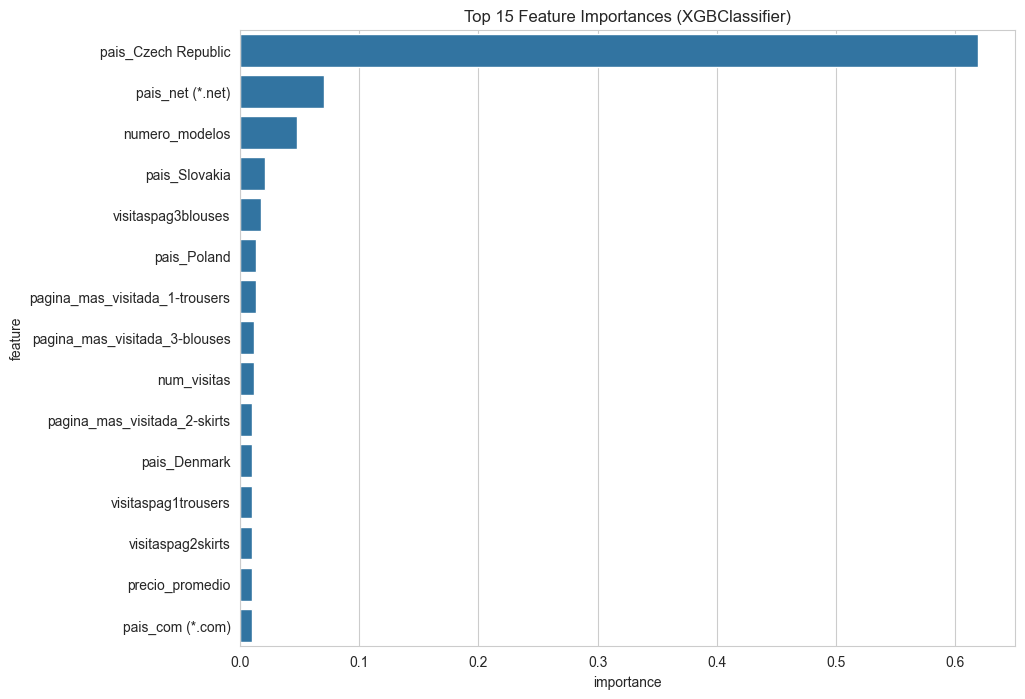

In [ ]:
plot_feature_importance(xgb_pipeline)

La variable con la mayor importancia (61%) fue la variable binaria `pais_Czech Republic`, indicando que las sesiones de usuario registradas desde República Checa tienden a registrar compras con más frecuencia.

# 4. SHAP - Tree Explainer

## 4.1. Cálculo de SHAP Values

In [ ]:
# Inicializar JS
shap.initjs()

In [ ]:
# Calculando SHAP values para XGBoost classifier
print("Calculando SHAP values para XGBoost classifier...")
explainer = shap.TreeExplainer(xgb_pipeline.named_steps['model'])
shap_values = explainer.shap_values(X_test)

# Corrección de formato para versiones nuevas de SHAP (si devuelve lista)
if isinstance(shap_values, list):
    shap_values = shap_values[1] # Tomamos la clase positiva (Ingreso a página de compra 'sales')
    
print("Valores SHAP calculados.")

## 4.2. Gráficos

### a. Beeswarm Plot

In [ ]:
plt.title("Impacto de las variables en la Fuga (SHAP Summary)")
shap.summary_plot(shap_values, X_test, show=False)
plt.show()

### b. Absolute Mean SHAP

In [ ]:
plt.title("Media Absoluta de valores SHAP por variable")
shap.plots.bar(shap_values, max_display=15)
plt.show()

### c. Stacked Force Plot

In [ ]:
plt.title("Impacto individual de las primeras 100 predicciones (SHAP Force Plot)")
shap.plots.force(shap_values[0:100])
plt.show()

### d. Dependence Plot

🚧🚧POR MODIFICAR

In [ ]:
variable1 = 'num_visitas'
variable2 = 'precio_promedio'

> **Gráfico 1**

In [ ]:
plt.title(f"Relación entre valor de {variable1} y su impacto (SHAP Scatter Plot)")
shap.plots.scatter(shap_values[:, variable1])
plt.show()

> **Gráfico 2**

In [ ]:
plt.title(f"Relación entre valor de {variable2} y su impacto (SHAP Scatter Plot)")
shap.plots.scatter(shap_values[:, variable2])
plt.show()

> **Gráfico 3**

In [ ]:
plt.title(f"Relación entre valor de {variable1} y su impacto, coloreado por {variable2} (SHAP Scatter Plot)")
shap.plots.scatter(shap_values[:, variable1],
                   color = shap_values[:, variable2])
plt.show()

In [ ]:
shap.dependence_plot(
    variable1, 
    shap_values, 
    X_test, 
    interaction_index=variable2,
    show=False
)
plt.title(f"Dependence Plot of {variable1} colored by {variable2}")
plt.show()

# 5. Interpretabilidad local

Encontrar en primer lugar la sesión (punto de datos) con mayor probabilidad de entrar a la página de compras (clase positiva):

In [ ]:
probs = xgb_pipeline.predict_proba(X_test)[:, 1]

max_probs_idx = np.argmax(probs)
sesion_max_prob = X_test.iloc[max_probs_idx]

print(f"Sesión con mayor probabilidad de compra (sales): {max_probs_idx}")
print(f"Probabilidad de la sesión de entrar a página de compras 'sales': {probs[max_probs_idx]: .4f}")

## 5.1. Gráficos SHAP

### a. SHAP Waterfall Plot

Generar a continuación el `Waterfall Plot` para este caso individual:

In [ ]:
plt.title(f"Waterfall SHAP Plot para la sesión con mayor probabilidad de compra (sales)")

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[max_probs_idx], 
        base_values=explainer.expected_value, 
        data=sesion_max_prob,
        feature_names=X_test.columns
    )
)

plt.show()

### b. SHAP Force plot

In [ ]:
plt.title("Force SHAP Plot para la sesión con mayor probabilidad de compra (sales)")

shap.plots.force(
    shap.Explanation(
        values=shap_values[max_probs_idx], 
        base_values=explainer.expected_value, 
        data=sesion_max_prob,
        feature_names=X_test.columns
    )
)

plt.show()

## 5.2. Gráficos LIME

In [ ]:
# Entrenamos un clasificador para LIME
model_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model_clf.fit(X_train, y_train)

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    # feature_names=[variable1, variable2],
    class_names=['Clase 0', 'Clase 1'],
    mode='classification',
    kernel_width=0.75 # El parámetro sigma en la fórmula del kernel
)

In [ ]:
# Explicación de una sesión
i = sesion_max_prob.name  # Índice de la sesión con mayor probabilidad
exp = explainer.explain_instance(X.iloc[i], model_clf.predict_proba) #, num_features=2)

In [ ]:
# Visualizamos los coeficientes del modelo local 'g'
# Estos NO son los coeficientes globales, son los coeficientes de la regresión ponderada local
print(f"Coeficientes del modelo local g(z) para la sesión {i}:")
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")

exp.as_pyplot_figure()
plt.title(f"Aproximación Lineal Local para x={X.iloc[i].values}")
plt.show()

# 6. Conclusiones